# **Outlier Detection using IQR**

In [17]:
# This is used when data is skewed

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv('/content/placement.csv')
df.sample(4)

,cgpa,placement_exam_marks,placed
173,6.71,48.0,0
404,8.02,35.0,1
151,7.29,16.0,1
84,5.65,35.0,1


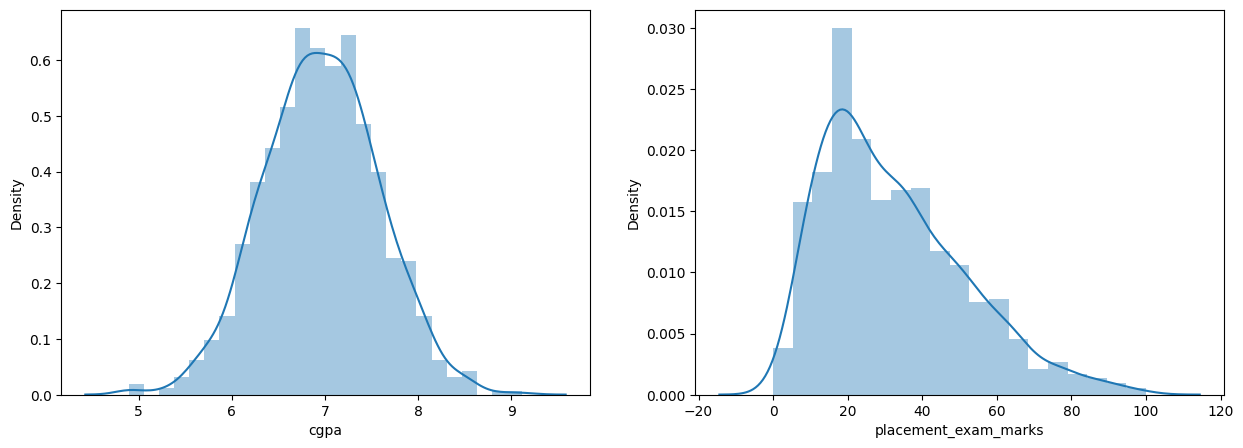

In [20]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])
plt.show()

In [21]:
df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [22]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

**So here we can see placement_exam_marks are right skewed and cgpa is normally distributed from the visualization and the skew() Right!!**

In [23]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


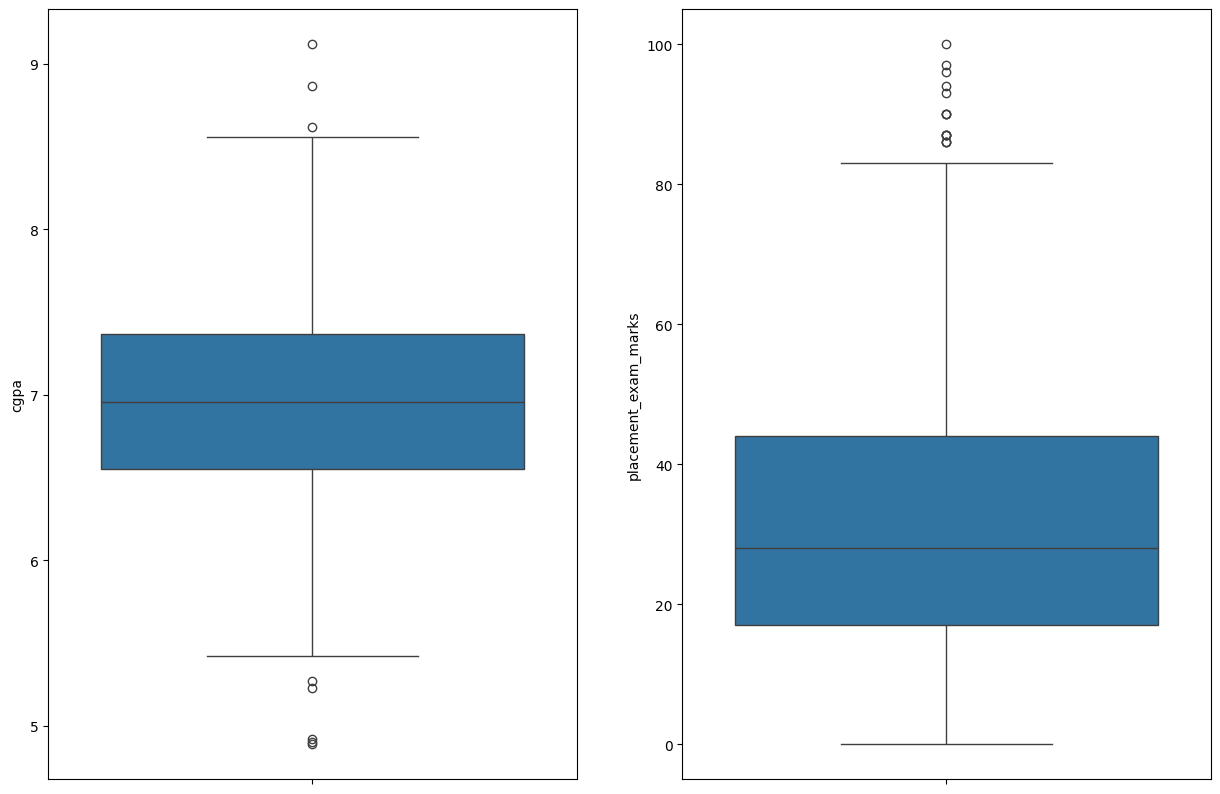

In [24]:
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
sns.boxplot(df['cgpa'])

plt.subplot(1,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.show()

here we can see the outliers in the placement one

In [25]:
#Now Evaluating the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

IQR = (percentile75 - percentile25)
IQR

np.float64(27.0)

In [28]:
upper_limit = percentile75 + 1.5*(IQR)
lower_limit = percentile25 - 1.5*(IQR)
print(upper_limit)
print(lower_limit)

84.5
-23.5


In [29]:
df[df['placement_exam_marks']> upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [30]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


# **Trimming**

In [31]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [32]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


# **Compare**

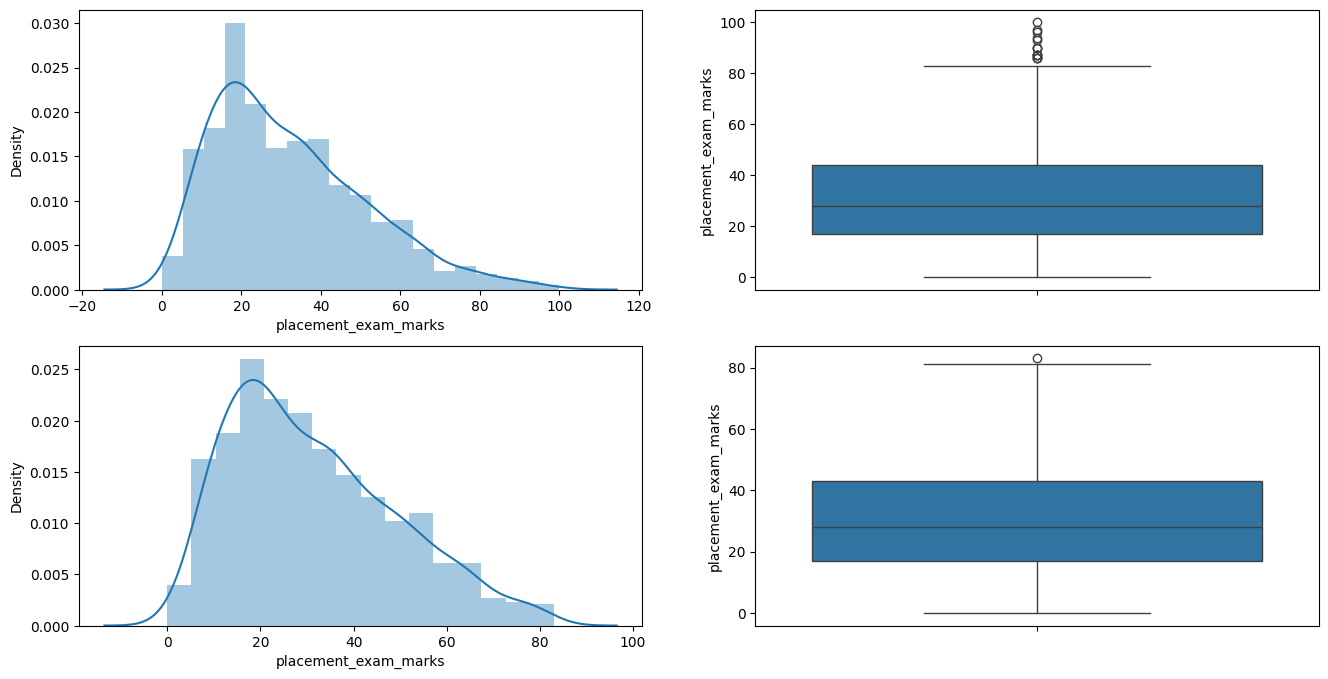

In [34]:
plt.figure(figsize =(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])
plt.show()

# **Capping**

In [35]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [36]:
# np.where(condition,True,False)

In [37]:
new_df_cap.shape

(1000, 3)

<Axes: ylabel='placement_exam_marks'>

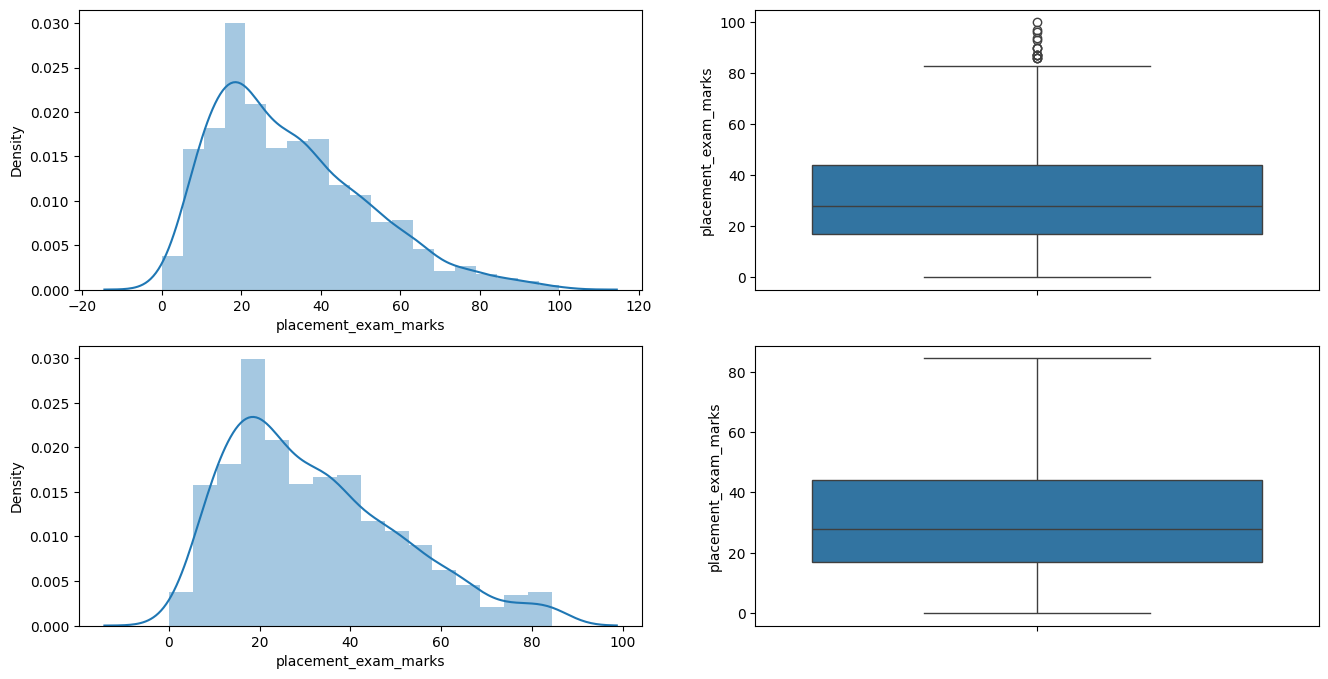

In [38]:
#Comparing for Capping

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])